# Morfologi Citra

Praktikum: Deteksi Tepi dan Morfologi Citra

Praktikum ini berisi contoh kode dan instruksi untuk menerapkan **Sobel**, **Canny**, serta operasi morfologi (**erosi**, **dilasi**, **opening**, **closing**) menggunakan Python + OpenCV.

**Petunjuk:** jalankan tiap cell satu-per-satu. Jika tidak memiliki `lenna.png`, notebook menggunakan gambar default dari `skimage.data`.

## 1. Setup environment
Install library yang diperlukan jika belum ada: `opencv-python`, `matplotlib`, `scikit-image`, `numpy`. Jalankan cell berikut jika perlu.

In [1]:
# Jika perlu, uncomment baris pip install berikut
# pip install --quiet opencv-python matplotlib scikit-image numpy

print("Libraries ready (if already installed).")


Libraries ready (if already installed).


## 2. Load image
Coba muat `data/lenna.png` jika tersedia. Jika tidak, gunakan gambar default dari `skimage.data` (camera).

Using: local lenna.png


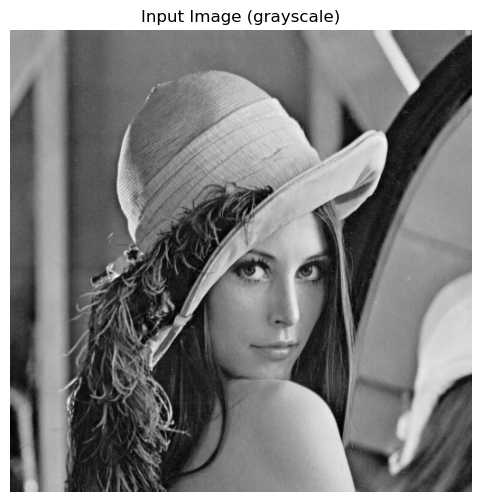

In [2]:
import os
import cv2
import numpy as np
from skimage import data, img_as_ubyte
import matplotlib.pyplot as plt

# Paths
local_path = "Assets/data/lenna.png"
if os.path.exists(local_path):
    img_bgr = cv2.imread(local_path)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    source = "local lenna.png"
else:
    # fallback image from skimage
    img = data.camera()  # grayscale
    img_gray = img_as_ubyte(img)
    img_bgr = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)
    source = "skimage.data.camera()"

print("Using:", source)
plt.figure(figsize=(6,6))
plt.imshow(img_gray, cmap='gray')
plt.title("Input Image (grayscale)")
plt.axis('off')
plt.show()


## 3. Sobel Edge Detection
Hitung gradien arah X dan Y lalu magnitude. Kita gunakan OpenCV `Sobel` dan `cv2.magnitude`.

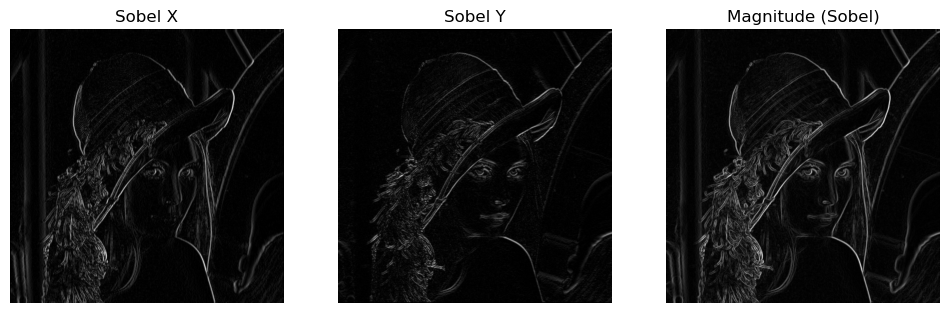

In [3]:
# Sobel
sobelx = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
mag = cv2.magnitude(sobelx, sobely)
# Normalize magnitude for display
mag_norm = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(np.abs(sobelx), cmap='gray'); plt.title('Sobel X'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(np.abs(sobely), cmap='gray'); plt.title('Sobel Y'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(mag_norm, cmap='gray'); plt.title('Magnitude (Sobel)'); plt.axis('off')
plt.show()


## 4. Canny Edge Detection
Gunakan `cv2.Canny`. Eksperimen dengan threshold bawah dan atas. Juga tunjukkan efek smoothing (Gaussian) sebelum Canny.

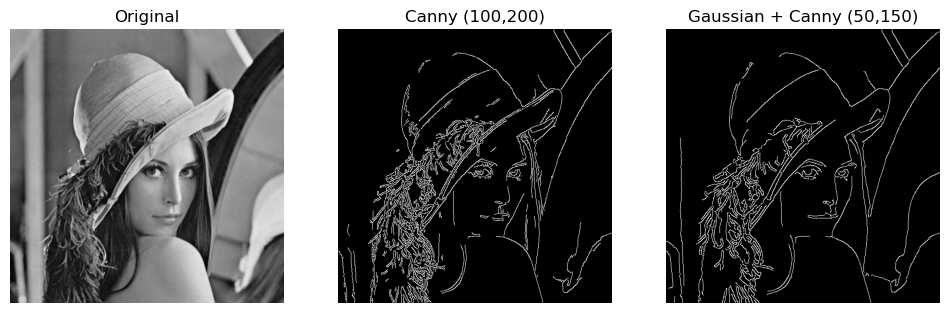

In [4]:
# Canny with default thresholds
edges = cv2.Canny(img_gray, 100, 200)

# Canny with Gaussian smoothing first
blur = cv2.GaussianBlur(img_gray, (5,5), 1.4)
edges_blur = cv2.Canny(blur, 50, 150)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img_gray, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(edges, cmap='gray'); plt.title('Canny (100,200)'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(edges_blur, cmap='gray'); plt.title('Gaussian + Canny (50,150)'); plt.axis('off')
plt.show()


## 5. Operasi Morfologi

Operasi ini bekerja pada citra biner. Kita akan threshold hasil Canny untuk mendapatkan biner, lalu terapkan operasi morfologi.
- Erosi
- Dilasi
- Opening
- Closing

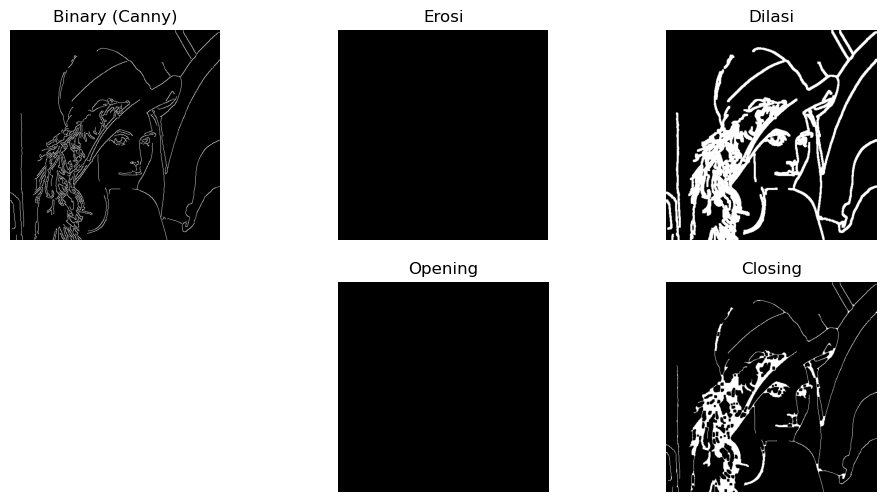

In [5]:
# Convert edges to binary (0/255)
_, binary = cv2.threshold(edges_blur, 1, 255, cv2.THRESH_BINARY)

kernel = np.ones((5,5), np.uint8)

erosion = cv2.erode(binary, kernel, iterations=1)
dilation = cv2.dilate(binary, kernel, iterations=1)
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(12,6))
plt.subplot(2,3,1); plt.imshow(binary, cmap='gray'); plt.title('Binary (Canny)'); plt.axis('off')
plt.subplot(2,3,2); plt.imshow(erosion, cmap='gray'); plt.title('Erosi'); plt.axis('off')
plt.subplot(2,3,3); plt.imshow(dilation, cmap='gray'); plt.title('Dilasi'); plt.axis('off')
plt.subplot(2,3,5); plt.imshow(opening, cmap='gray'); plt.title('Opening'); plt.axis('off')
plt.subplot(2,3,6); plt.imshow(closing, cmap='gray'); plt.title('Closing'); plt.axis('off')
plt.show()


## 6. Deteksi Kontur Sederhana
Gabungkan Canny + morphology untuk mendapatkan kontur yang lebih rapih lalu ekstrak kontur menggunakan `cv2.findContours`.

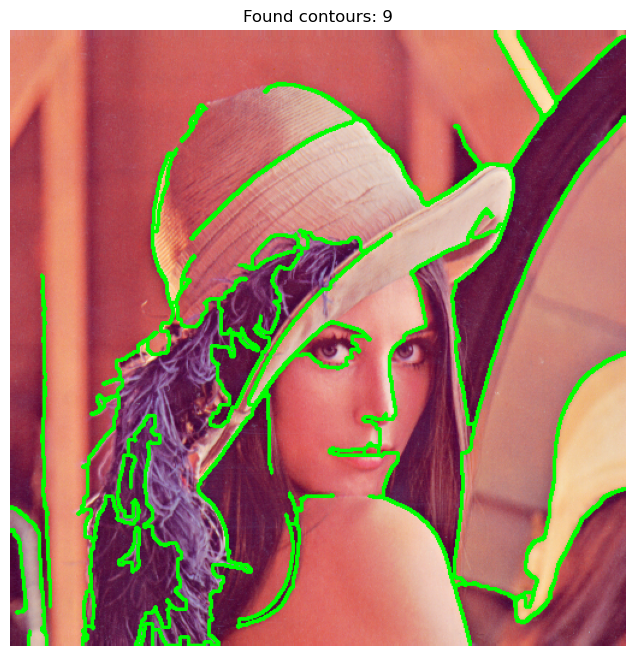

In [6]:
# Use closing to fill small gaps, then find contours
proc = closing.copy()
contours, hierarchy = cv2.findContours(proc, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Draw contours on original (color) image
img_contour = img_bgr.copy()
cv2.drawContours(img_contour, contours, -1, (0,255,0), 2)

# Convert BGR to RGB for matplotlib
img_contour_rgb = cv2.cvtColor(img_contour, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(img_contour_rgb); plt.title(f'Found contours: {len(contours)}'); plt.axis('off')
plt.show()


## 7. Latihan / Tugas
1. Ubah ukuran kernel morfologi (3x3, 7x7) dan amati efeknya.
2. Eksperimen dengan iterasi pada erosi/dilasi.
3. Terapkan pipeline pada citra berbeda (mis. shapes.png atau coins.png).
4. Buat laporan singkat dan sertakan screenshot hasil.

### 1. Variasi Ukuran Kernel (3x3 vs 7x7)

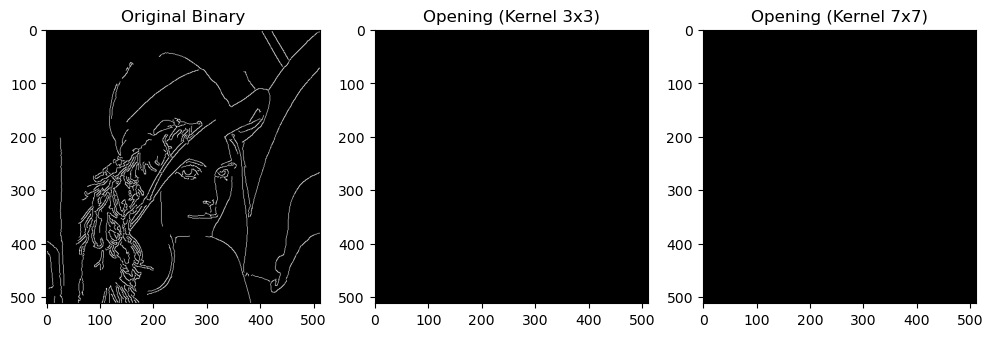

In [7]:
# Definisi kernel
k3 = np.ones((3,3), np.uint8)
k7 = np.ones((7,7), np.uint8)

# Operasi Opening (Erosi -> Dilasi)
opening_k3 = cv2.morphologyEx(binary, cv2.MORPH_OPEN, k3)
opening_k7 = cv2.morphologyEx(binary, cv2.MORPH_OPEN, k7)

# Visualisasi
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1); plt.imshow(binary, cmap='gray'); plt.title('Original Binary')
plt.subplot(1, 3, 2); plt.imshow(opening_k3, cmap='gray'); plt.title('Opening (Kernel 3x3)')
plt.subplot(1, 3, 3); plt.imshow(opening_k7, cmap='gray'); plt.title('Opening (Kernel 7x7)')
plt.show()

Analisis:
- Kernel 3x3: Noise kecil (bintik putih sangat kecil) akan hilang, tapi detail objek utama masih terjaga.
- Kernel 7x7: Efeknya jauh lebih agresif. Objek-objek kecil atau garis tipis mungkin akan hilang sepenuhnya. Objek besar akan menjadi lebih halus (kurang detail) dibandingkan kernel 3x3.

### 2. Eksperimen Iterasi (Dilasi)

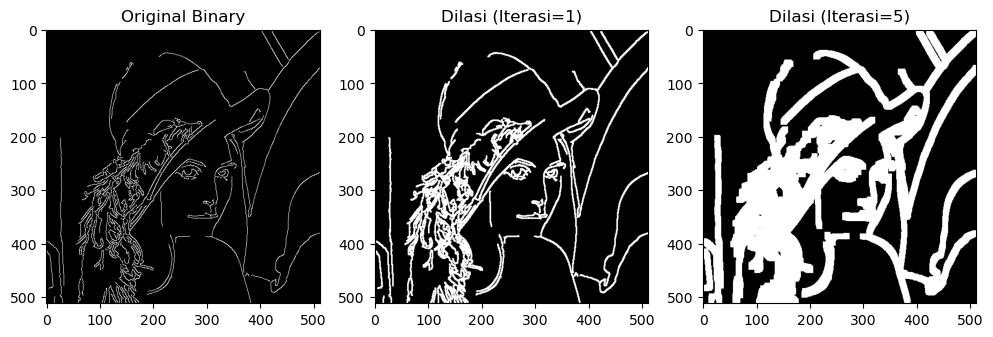

In [8]:
kernel = np.ones((3,3), np.uint8)

# Dilasi dengan iterasi berbeda
dilasi_1 = cv2.dilate(binary, kernel, iterations=1)
dilasi_5 = cv2.dilate(binary, kernel, iterations=5)

plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1); plt.imshow(binary, cmap='gray'); plt.title('Original Binary')
plt.subplot(1, 3, 2); plt.imshow(dilasi_1, cmap='gray'); plt.title('Dilasi (Iterasi=1)')
plt.subplot(1, 3, 3); plt.imshow(dilasi_5, cmap='gray'); plt.title('Dilasi (Iterasi=5)')
plt.show()

Analisis:
- Iterasi 1: Garis tepi menebal sedikit, menutup celah yang sangat kecil.
- Iterasi 5: Garis tepi menjadi sangat tebal (gemuk). Jika ada dua objek yang berdekatan, mereka kemungkinan besar akan menyatu (merge) menjadi satu blob besar.

### 3. Pipeline pada Citra Berbeda (coins)

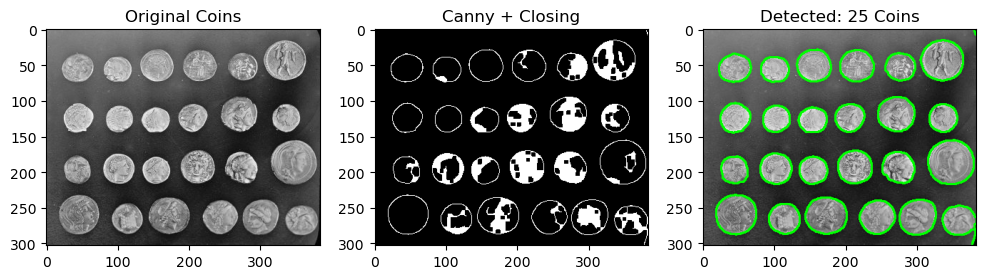

In [9]:
# Load image coins
coins = data.coins() # Ini sudah grayscale

# 1. Preprocessing (Gaussian Blur)
coins_blur = cv2.GaussianBlur(coins, (5,5), 1.5)

# 2. Canny Edge Detection
# Threshold disesuaikan untuk koin
coins_edges = cv2.Canny(coins_blur, 30, 150)

# 3. Morfologi: Closing untuk menutup garis tepi koin agar menyambung
kernel_coin = np.ones((5,5), np.uint8)
coins_closed = cv2.morphologyEx(coins_edges, cv2.MORPH_CLOSE, kernel_coin)

# 4. Find Contours & Draw
contours_coins, _ = cv2.findContours(coins_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
coins_result = cv2.cvtColor(coins, cv2.COLOR_GRAY2BGR)
cv2.drawContours(coins_result, contours_coins, -1, (0, 255, 0), 2)

# Visualisasi
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(coins, cmap='gray'); plt.title('Original Coins')
plt.subplot(1, 3, 2); plt.imshow(coins_closed, cmap='gray'); plt.title('Canny + Closing')
plt.subplot(1, 3, 3); plt.imshow(coins_result); plt.title(f'Detected: {len(contours_coins)} Coins')
plt.show()

### 4. Draft Laporan Singkat

**1. Pengaruh Ukuran Kernel**
Berdasarkan percobaan, ukuran kernel mempengaruhi seberapa luas area tetangga yang diproses.
* Pada operasi **Opening** dengan kernel **3x3**, noise latar belakang (salt noise) berkurang namun bentuk asli objek masih tajam.
* Saat kernel diperbesar menjadi **7x7**, operasi menjadi lebih destruktif. Struktur detail yang lebih kecil dari 7x7 piksel hilang sepenuhnya. Ini berguna jika noise berukuran besar, tetapi berisiko merusak bentuk objek utama.

**2. Pengaruh Iterasi**
Parameter `iterations` mengulang operasi morfologi sebanyak  kali.
* Pada **Dilasi**, iterasi tinggi menyebabkan area putih (foreground) meluas secara signifikan. Hal ini berguna untuk menghubungkan komponen yang terputus agak jauh, namun dapat menyebabkan objek-objek terpisah menjadi menyatu (merging) secara tidak diinginkan.

**3. Studi Kasus: Deteksi Koin**
Penerapan pipeline (*Gaussian -> Canny -> Closing -> FindContours*) pada citra `coins` berhasil mendeteksi tepi koin.
* **Masalah:** Canny saja sering menghasilkan garis tepi yang putus-putus.
* **Solusi:** Operasi Morfologi **Closing** (Dilasi lalu Erosi) sangat krusial di sini untuk menyambungkan garis-garis Canny yang putus tersebut menjadi satu loop tertutup, sehingga `findContours` dapat mengenali koin sebagai satu objek utuh.